# Início: Preparação dos dados

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import random as rd
import os
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from scipy import stats

In [19]:
%matplotlib inline

# @grellert: removendo warnings chatos
import sys

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")


In [49]:
df = pd.read_csv(os.path.join('..','dados', 'brutos', 'heart_disease_dataset.csv'))

In [28]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [29]:
df = df.dropna()
print(df)

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0      172              N  

In [23]:
np.where(pd.isnull(df))

(array([], dtype=int64), array([], dtype=int64))

In [24]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
count,3069.00000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000,3069.000000
mean,52.50114,0.555556,2.489736,145.306289,347.219941,0.145650,1.004236,135.157380,0.176279,3.189052,2.023786,0.626588,4.544477,0.348974,0.193874,27.496839,0.388074
std,13.70752,0.496985,1.110417,31.602321,146.853319,0.352813,0.812016,43.353197,0.381119,1.802815,0.817679,0.891447,1.751064,0.476723,0.395396,7.281731,0.487391
min,29.00000,0.000000,1.000000,90.000000,100.000000,0.000000,0.000000,60.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,15.000000,0.000000
25%,41.00000,0.000000,2.000000,118.000000,215.000000,0.000000,0.000000,98.000000,0.000000,1.600000,1.000000,0.000000,3.000000,0.000000,0.000000,21.300000,0.000000
50%,53.00000,1.000000,2.000000,146.000000,350.000000,0.000000,1.000000,135.000000,0.000000,3.200000,2.000000,0.000000,3.000000,0.000000,0.000000,27.400000,0.000000
75%,64.00000,1.000000,3.000000,172.000000,475.000000,0.000000,2.000000,172.000000,0.000000,4.700000,3.000000,1.000000,6.000000,1.000000,0.000000,33.900000,1.000000
max,76.00000,1.000000,4.000000,200.000000,600.000000,1.000000,2.000000,210.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000,1.000000,40.000000,1.000000


In [52]:
TH_CATEGORICO = 5
categoricos = [] 
string = []
quantitativos = []
nao_numericos = []

for col in df:
    unicos = df[col].unique()
    ## dividindo colunas entre valores categoricos e quantitativos:
    if unicos.shape[0] < TH_CATEGORICO:
        categoricos.append(col)
    else: 
        quantitativos.append(col)
print(f'colunas categoricas: {len(categoricos)}, quantitativas: {len(quantitativos)}')

colunas categoricas: 11, quantitativas: 6


In [61]:
for quantitativos in df:
    print(f"{quantitativos}:", df[quantitativos].unique())

age: [67 57 43 71 36 49 47 51 39 52 64 68 31 50 30 72 58 66 61 40 53 55 70 56
 44 75 65 35 37 46 32 42 54 48 63 45 34 62 38 59 76 73 69 29 33 41 60 74]
sex: [1 0]
cp: [2 3 4 1]
trestbps: [111 109 171  90 119 186 113 103 125 158 164 149 184 144 166 169 143 115
 155 127 199 154 140 124 132 118 126 170 147 128 131 117  92  99 148 195
 165 136 183 121 145  91 192 160 141 180  98 123 138 162 173 142 172 189
 129 134 157 194 107  95 137 200  96 105 153 179 175 151 161 150 122 196
 163  93 178 177 174 104 188 146 130 176 112 197 114 152 159 120 187 182
 168  97 193 191 190 110  94 198 106 102 100 185 139 133 135 108 167 101
 156 181 116]
chol: [536 107 508 523 131 571 127 305 592 486 327 227 354 574 311 338 306 417
 382 344 144 204 447 380 333 288 143 593 324 529 241 235 275 548 179 181
 234 443 276 482 342 154 240 556 539 155 114 284 413 518 187 196 243 576
 314 272 322 139 596 281 369 286 577 408 330 254 274 435 214 489 410 580
 399 117 371 111 503 400 291 331 542 192 317 377 452 600 586 40

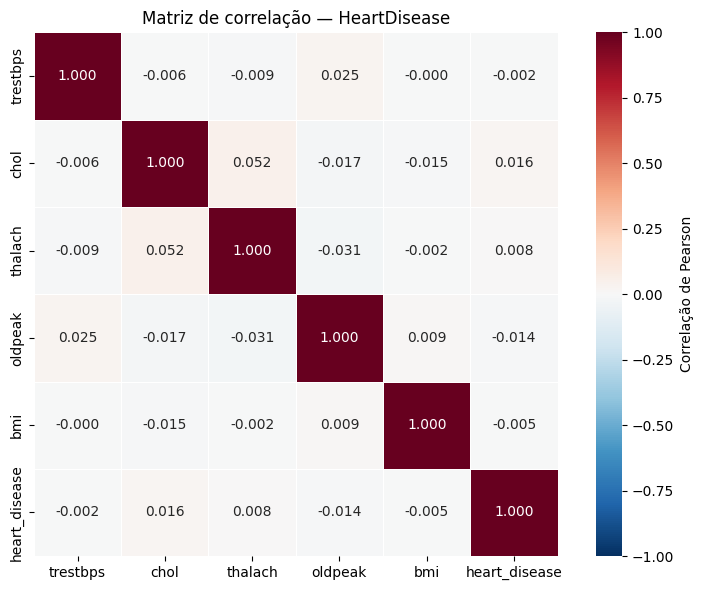

In [62]:
# =========================================================
# HEATMAP DE CORRELAÇÃO — HEARTDISEASE
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garante cópia da base
df_heart = df.copy()

selected_cols = [
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "bmi"
]

target_col = "heart_disease"

# Garante formato numérico
for col in selected_cols + [target_col]:
    df_heart[col] = pd.to_numeric(df_heart[col], errors="coerce")

# Mantém apenas linhas válidas
df_corr = df_heart[selected_cols + [target_col]].dropna().copy()

# Correlação de Pearson
corr = df_corr.corr(method="pearson")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlação de Pearson"}
)

plt.title("Matriz de correlação — HeartDisease")
plt.tight_layout()
plt.show()

# Fase I - Estatística

Distribuição da variável alvo — HeartDisease:
heart_disease
0    0.611926
1    0.388074
Name: proportion, dtype: float64

Tamanho da base:
Amostras: 3069

Iniciando coleta de distribuições...
Total de cenários: 1600
--------------------------------------------------

 Atributo atual: trestbps
   % faltante: 5%
      Progresso: 10/1600 (0.6%) | Tempo decorrido: 0.0 min | ETA: 6.5 min
      Progresso: 20/1600 (1.2%) | Tempo decorrido: 0.1 min | ETA: 6.2 min
      Progresso: 30/1600 (1.9%) | Tempo decorrido: 0.1 min | ETA: 6.1 min
      Progresso: 40/1600 (2.5%) | Tempo decorrido: 0.2 min | ETA: 6.0 min
      Progresso: 50/1600 (3.1%) | Tempo decorrido: 0.2 min | ETA: 5.9 min
      Progresso: 60/1600 (3.8%) | Tempo decorrido: 0.2 min | ETA: 5.8 min
      Progresso: 70/1600 (4.4%) | Tempo decorrido: 0.3 min | ETA: 5.8 min
      Progresso: 80/1600 (5.0%) | Tempo decorrido: 0.3 min | ETA: 5.7 min
      Progresso: 90/1600 (5.6%) | Tempo decorrido: 0.3 min | ETA: 5.7 min
      Progresso: 100/1

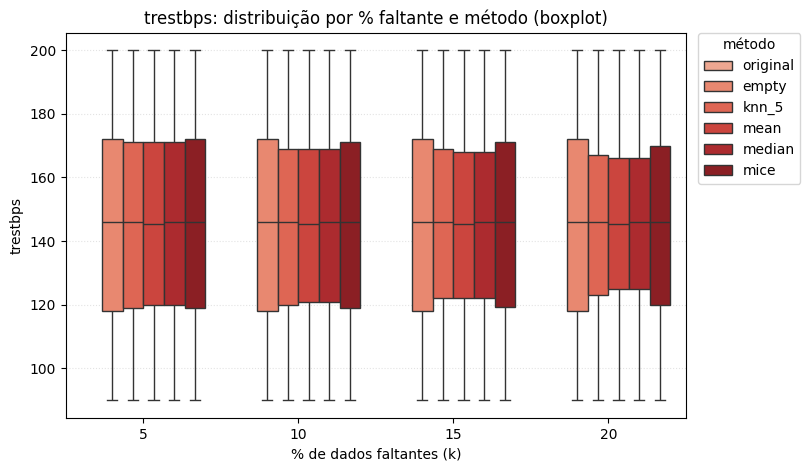

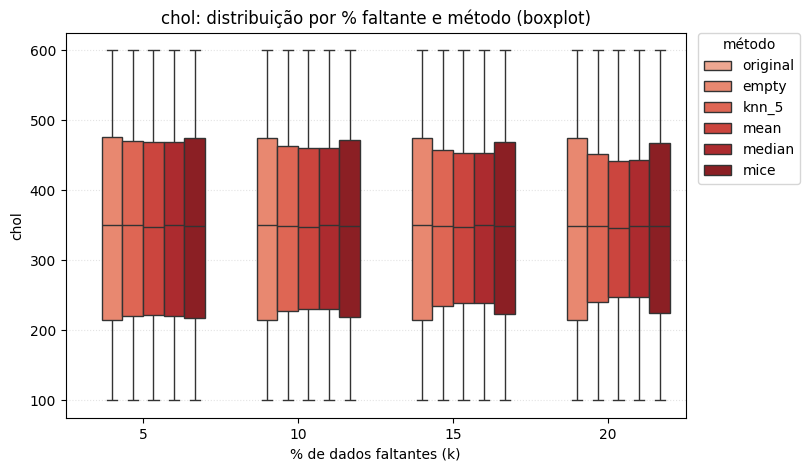

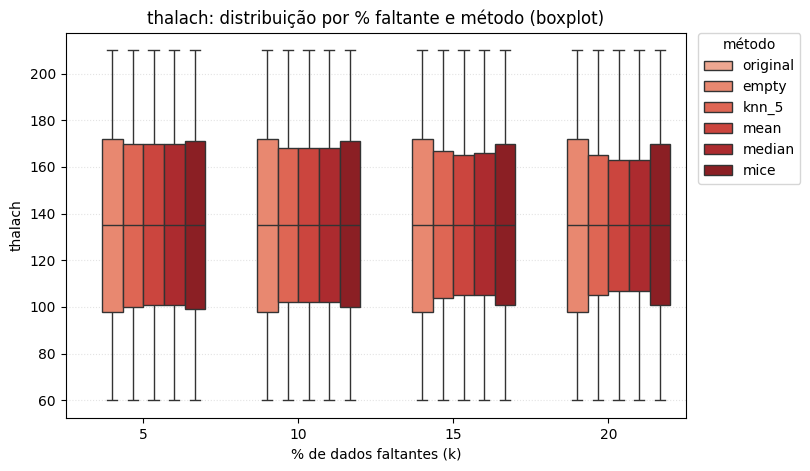

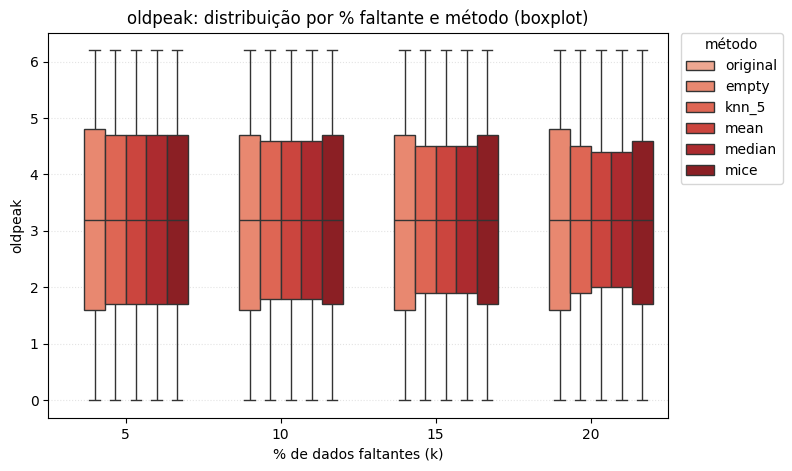

In [14]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge

# ---------------------------------------------------------
# Helpers: aplicar uma imputação sobre um X_nan JÁ mascarado
# ---------------------------------------------------------
def _apply_imputation(X_nan: pd.DataFrame, method: str, seed: int | None = None) -> pd.DataFrame:
    """Aplica imputação no DataFrame X_nan (com NaNs já aplicados).
       Retorna um DataFrame imputado (todas as colunas numéricas)."""
    if method == "mean":
        Xi = X_nan.copy()
        for c in Xi.columns:
            Xi[c] = Xi[c].fillna(Xi[c].mean())
        return Xi

    if method == "median":
        Xi = X_nan.copy()
        for c in Xi.columns:
            Xi[c] = Xi[c].fillna(Xi[c].median())
        return Xi

    if method.startswith("knn_"):
        try:
            n = int(method.split("_", 1)[1])
        except Exception:
            raise ValueError("Use método como 'knn_5', 'knn_7', etc.")
        imp = KNNImputer(n_neighbors=n)
        return pd.DataFrame(imp.fit_transform(X_nan), columns=X_nan.columns, index=X_nan.index)

    if method == "mice":
        col_mins = X_nan.quantile(0.01, numeric_only=True).reindex(X_nan.columns).to_numpy()
        col_maxs = X_nan.quantile(0.99, numeric_only=True).reindex(X_nan.columns).to_numpy()
        Xnum = X_nan.to_numpy(dtype=float)
        col_mins = np.where(np.isfinite(col_mins), col_mins, np.nanmin(Xnum, axis=0))
        col_maxs = np.where(np.isfinite(col_maxs), col_maxs, np.nanmax(Xnum, axis=0))

        imp = IterativeImputer(
            max_iter=20,
            imputation_order="ascending",
            initial_strategy="median",
            skip_complete=True,
            sample_posterior=False,
            min_value=col_mins,
            max_value=col_maxs,
            random_state=seed,
        )
        return pd.DataFrame(imp.fit_transform(X_nan), columns=X_nan.columns, index=X_nan.index)
    
    # if method == "missforest":
    #     est = RandomForestRegressor(
    #         n_estimators=200,
    #         random_state=seed,
    #         n_jobs=-1
    #     )
    #     imp = IterativeImputer(
    #         estimator=est,
    #         max_iter=10,
    #         initial_strategy="median",
    #         skip_complete=True,
    #         random_state=seed
    #     )
    #     return pd.DataFrame(imp.fit_transform(X_nan), columns=X_nan.columns, index=X_nan.index)

    if method == "empty":
        return X_nan.copy()

    raise ValueError(f"Método inválido: {method}")

def get_observed_bounds(X_nan: pd.DataFrame):
    """
    Define limites usando mínimo e máximo observados em cada coluna.
    É mais neutro que usar percentis 1% e 99%, pois não corta extremos reais.
    """
    Xnum = X_nan.to_numpy(dtype=float)

    col_mins = np.nanmin(Xnum, axis=0)
    col_maxs = np.nanmax(Xnum, axis=0)

    return col_mins, col_maxs

def _apply_mice_mi(
    X_nan: pd.DataFrame,
    seed: int | None = None,
    m: int = 5
) -> list[pd.DataFrame]:
    """
    Aplica MICE como imputação múltipla.
    Retorna uma lista com m DataFrames imputados.
    """

    col_mins, col_maxs = get_observed_bounds(X_nan)

    imputed_datasets = []

    for i in range(m):
        imp = IterativeImputer(
            estimator=BayesianRidge(),
            max_iter=20,
            imputation_order="ascending",
            initial_strategy="median",
            skip_complete=True,
            sample_posterior=True,
            min_value=col_mins,
            max_value=col_maxs,
            random_state=None if seed is None else seed + i
        )

        Xi = pd.DataFrame(
            imp.fit_transform(X_nan),
            columns=X_nan.columns,
            index=X_nan.index
        )

        imputed_datasets.append(Xi)

    return imputed_datasets

# ---------------------------------------------------------
# Coletar "dados brutos" (valores) para plotar as distribuições
# ---------------------------------------------------------
import time

def collect_raw_distributions(
    X: pd.DataFrame,
    y: pd.Series,
    columns: list[str],
    methods: list[str],
    ks=(5, 10, 15, 20),
    reps=10,
    missing_mech="MCAR",
    seed_base=2025,
    sample_per_cell: int | None = 2000,
    pick_missing_indices=None,
    verbose=True
):
    assert pick_missing_indices is not None, "Passe sua função pick_missing_indices."
    rows = []

    total_steps = len(columns) * len(ks) * reps
    step = 0
    t0 = time.time()

    if verbose:
        print(f"\nIniciando coleta de distribuições...")
        print(f"Total de cenários: {total_steps}")
        print("-" * 50)

    for col in columns:
        if verbose:
            print(f"\n Atributo atual: {col}")

        v_orig_full = X[col].to_numpy()

        for k in ks:
            if verbose:
                print(f"   % faltante: {k}%")

            for r in range(reps):
                step += 1
                seed = seed_base + 1000 * k + r
                rng = np.random.default_rng(seed)

                X_nan = X.copy(deep=True)
                to_nan = pick_missing_indices(missing_mech, X_nan, y, col, k, seed=seed)
                if len(to_nan) > 0:
                    X_nan.loc[to_nan, col] = np.nan

                # ORIGINAL
                v_orig = v_orig_full
                if sample_per_cell is not None and len(v_orig) > sample_per_cell:
                    v_orig = rng.choice(v_orig, size=sample_per_cell, replace=False)
                rows.extend((col, k, "original", r, float(v)) for v in v_orig if np.isfinite(v))

                # MÉTODOS
                for method in methods:
                    if method == "mice":
                        imputed_datasets = _apply_mice_mi(
                            X_nan,
                            seed=seed,
                            m=5
                        )

                        for imp_id, Xi in enumerate(imputed_datasets, start=1):
                            v_vals = Xi[col].to_numpy()

                            if sample_per_cell is not None and len(v_vals) > sample_per_cell:
                                v_vals = rng.choice(v_vals, size=sample_per_cell, replace=False)

                            rows.extend(
                                (col, k, method, r, imp_id, float(v))
                                for v in v_vals
                                if np.isfinite(v)
                            )

                    else:
                        Xi = _apply_imputation(X_nan, method, seed=seed)

                        if method == "empty":
                            v_vals = Xi[col].dropna().to_numpy()
                        else:
                            v_vals = Xi[col].to_numpy()

                        if sample_per_cell is not None and len(v_vals) > sample_per_cell:
                            v_vals = rng.choice(v_vals, size=sample_per_cell, replace=False)

                        rows.extend(
                            (col, k, method, r, 1, float(v))
                            for v in v_vals
                            if np.isfinite(v)
                        )

                # -------- PROGRESSO --------
                if verbose and (step % 10 == 0 or step == total_steps):
                    elapsed = time.time() - t0
                    progress = step / total_steps
                    eta = (elapsed / step) * (total_steps - step)

                    print(
                        f"      Progresso: {step}/{total_steps} "
                        f"({progress*100:.1f}%) | "
                        f"Tempo decorrido: {elapsed/60:.1f} min | "
                        f"ETA: {eta/60:.1f} min",
                        flush=True
                    )

    if verbose:
        total_time = time.time() - t0
        print("\n Finalizado!")
        print(f"Tempo total: {total_time/60:.2f} minutos")

    return pd.DataFrame(
        rows,
        columns=["attribute", "pct_imputed", "method", "rep", "imputation", "value"]
    )

# ---------------------------------------------------------
# Plots: BOX – x = % faltante, hue = método
# ---------------------------------------------------------
def plot_box_all_methods_one_axis(
    df_long: pd.DataFrame,
    attribute: str,
    order_pct: list[int] = (5, 10, 15, 20),
    showfliers: bool = False,
    height: float = 5.0,
    aspect: float = 1.6,
    legend_out: bool = True,
):
    dfp = df_long[df_long["attribute"] == attribute].copy()

    dfp["pct_imputed"] = pd.Categorical(
        dfp["pct_imputed"],
        categories=order_pct,
        ordered=True
    )

    base = ["original"]
    outros = sorted([m for m in dfp["method"].unique() if m not in base])
    order_methods = base + outros

    dfp["method"] = pd.Categorical(
        dfp["method"],
        categories=order_methods,
        ordered=True
    )

    # Paleta em tons de azul
    palette = sns.color_palette(
        "Reds",
        n_colors=len(order_methods) + 2
    )[2:]

    plt.figure(figsize=(height * aspect, height))

    ax = sns.boxplot(
        data=dfp,
        x="pct_imputed",
        y="value",
        hue="method",
        order=order_pct,
        hue_order=order_methods,
        palette=palette,
        showfliers=showfliers,
        flierprops={
            "marker": ".",
            "markersize": 3,
            "linestyle": "none",
            "markerfacecolor": "#1f4e79",
            "markeredgecolor": "#1f4e79"
        }
    )

    ax.set_xlabel("% de dados faltantes (k)")
    ax.set_ylabel(attribute)
    ax.set_title(f"{attribute}: distribuição por % faltante e método (boxplot)")

    if legend_out:
        ax.legend(
            title="método",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0
        )
    else:
        ax.legend(title="método")

    ax.grid(axis="y", linestyle=":", alpha=0.35)

    return ax

# ---------------------------------------------------------
# USO com HEARTDISEASE: desfecho binário + colunas selecionadas
# ---------------------------------------------------------
# 0) garanta que df já existe e que a base foi carregada anteriormente

df_heart = df.copy()

# 1) Desfecho: 0 = sem doença, 1 = com doença cardíaca
target_col = "heart_disease"

# 2) Colunas quantitativas analisadas, equivalentes às usadas no notebook anterior:
# trestbps = RestingBP, chol = Cholesterol, thalach = MaxHR, oldpeak = Oldpeak
selected_cols = [
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# 3) Garante formato numérico
for col in selected_cols + [target_col]:
    df_heart[col] = pd.to_numeric(df_heart[col], errors="coerce")

# 4) Mantém apenas linhas válidas para atributos e alvo
mask_valid = df_heart[selected_cols + [target_col]].notna().all(axis=1)

X = df_heart.loc[mask_valid, selected_cols].copy()
y = df_heart.loc[mask_valid, target_col].astype("int64").copy()

print("Distribuição da variável alvo — HeartDisease:")
print(y.value_counts(normalize=True).sort_index())

print("\nTamanho da base:")
print(f"Amostras: {len(X)}")

# 5) Função de mascaramento (MCAR simples)
def pick_missing_indices(missing_mech, X, y, col, k, seed=None):
    rng = np.random.default_rng(seed)
    candidates = X.index[X[col].notna()].to_numpy()  # só onde há dado observado
    m = int(round(len(candidates) * (k / 100.0)))
    m = min(m, len(candidates))
    return rng.choice(candidates, size=m, replace=False) if m > 0 else []

# 6) Rodar coleta e plotar
methods = ["empty", "mean", "median", "knn_5", "mice"]
ks = (5, 10, 15, 20)
reps = 100

df_long = collect_raw_distributions(
    X, y,
    columns=selected_cols,
    methods=methods,
    ks=ks,
    reps=reps,
    missing_mech="MCAR",
    seed_base=2025,
    sample_per_cell=2000,
    pick_missing_indices=pick_missing_indices,
    verbose=True
)

for attr in selected_cols:
    ax = plot_box_all_methods_one_axis(df_long, attr, order_pct=list(ks), showfliers=True)
    plt.show()


# Análise II — Machine Learning


Distribuição da variável alvo — HeartDisease:
heart_disease
0    0.611926
1    0.388074
Name: proportion, dtype: float64

Tamanho da base:
Amostras: 3069
[1/4000] 0.0% k=5% rep=1/100 method=empty model=logreg ETA=0.3min
[2/4000] 0.1% k=5% rep=1/100 method=empty model=tree_overfit ETA=73.2min
[3/4000] 0.1% k=5% rep=1/100 method=mean model=logreg ETA=80.6min
[4/4000] 0.1% k=5% rep=1/100 method=mean model=tree_overfit ETA=83.0min
[5/4000] 0.1% k=5% rep=1/100 method=median model=logreg ETA=82.7min
[6/4000] 0.1% k=5% rep=1/100 method=median model=tree_overfit ETA=69.5min
[7/4000] 0.2% k=5% rep=1/100 method=knn_5 model=logreg ETA=60.0min
[8/4000] 0.2% k=5% rep=1/100 method=knn_5 model=tree_overfit ETA=54.2min
[9/4000] 0.2% k=5% rep=1/100 method=mice model=logreg ETA=49.7min
[10/4000] 0.2% k=5% rep=1/100 method=mice model=tree_overfit ETA=54.4min
[11/4000] 0.3% k=5% rep=2/100 method=empty model=logreg ETA=57.7min
[12/4000] 0.3% k=5% rep=2/100 method=empty model=tree_overfit ETA=53.1min
[13/40

,pct_missing,method,model,f1,recall,precision,accuracy
0,0,original_dropna,logreg,0.4391,0.5072,0.3873,0.4969
1,0,original_dropna,tree_overfit,0.3813,0.3770,0.3861,0.5256
2,5,empty,logreg,0.4268,0.4872,0.3801,0.4915
3,5,empty,tree_overfit,0.3905,0.3904,0.3913,0.5266
4,5,knn_5,logreg,0.4269,0.4876,0.3800,0.4924
5,5,knn_5,tree_overfit,0.3885,0.3877,0.3900,0.5271
6,5,mean,logreg,0.4265,0.4869,0.3797,0.4921
7,5,mean,tree_overfit,0.3904,0.3903,0.3910,0.5275
8,5,median,logreg,0.4263,0.4867,0.3796,0.4920
9,5,median,tree_overfit,0.3891,0.3888,0.3900,0.5268


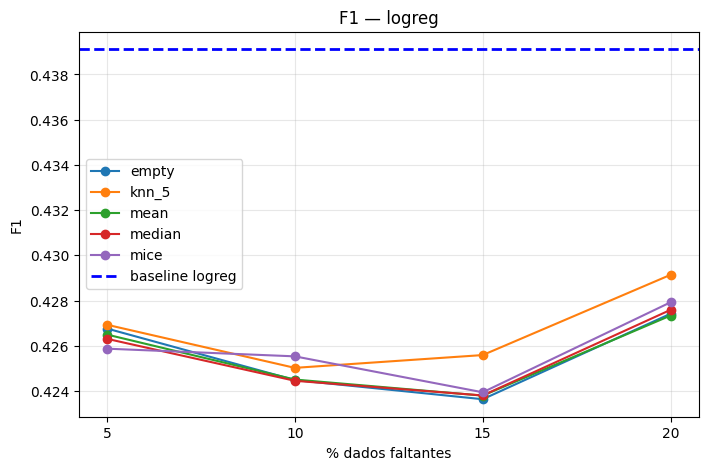

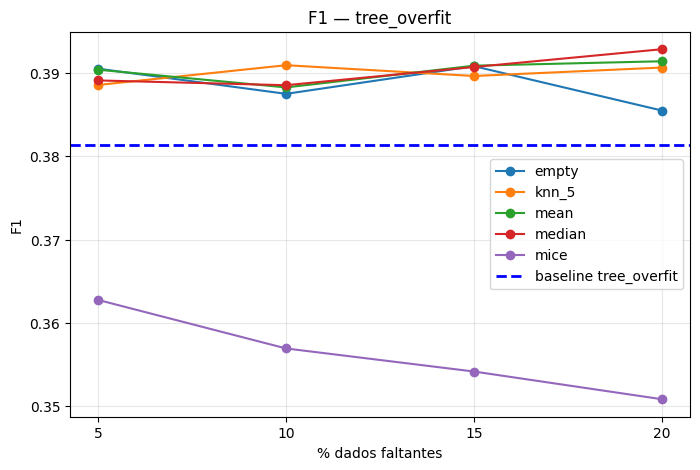

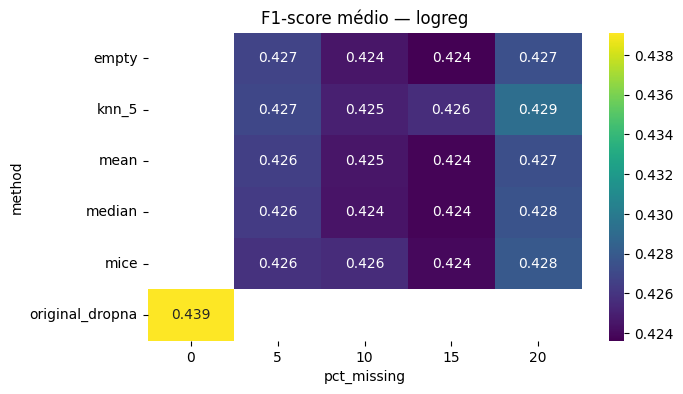

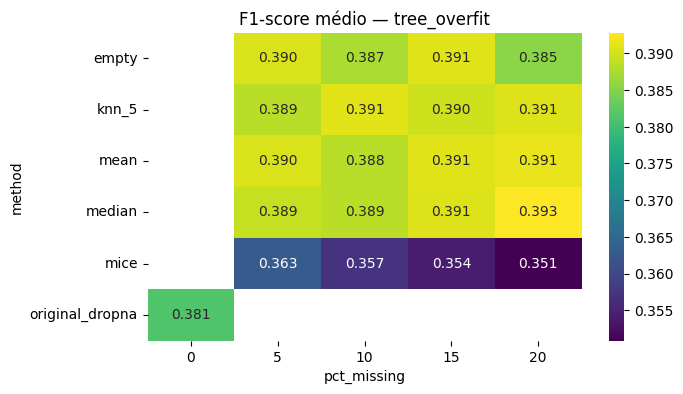

In [65]:
# =========================================================
# FASE 2 — ML (Regressão Logística + Árvore de Decisão Sobreajustada) + BASELINE ORIGINAL
# BASE HEARTDISEASE
# imputação feita dentro do fold (sem leakage)
# MICE ajustado para imputação múltipla (MI)
# =========================================================

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from joblib import Parallel, delayed

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    accuracy_score
)

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer


# =========================================================
# CONFIG
# =========================================================

selected_cols = [
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

target_col = "heart_disease"

# MICE aqui é MI de fato: gera múltiplas bases imputadas e combina as probabilidades
methods = ["empty", "mean", "median", "knn_5", "mice"]

# Número de imputações múltiplas para o MICE-MI
mice_m = 5

# Modelos avaliados:
# - logreg: modelo linear regularizado
# - tree_overfit: árvore de decisão praticamente sem poda, útil para observar sobreajuste
models = ["logreg", "tree_overfit"]

ks = (5, 10, 15, 20)
reps = 100
n_splits = 5
seed_base = 2025
n_jobs = -1


# =========================================================
# PREPARO DOS DADOS — HEARTDISEASE
# =========================================================

df_heart = df.copy()

for col in selected_cols + [target_col]:
    df_heart[col] = pd.to_numeric(df_heart[col], errors="coerce")

mask = df_heart[selected_cols + [target_col]].notna().all(axis=1)

X_full = df_heart.loc[mask, selected_cols].copy()
y_full = df_heart.loc[mask, target_col].astype("int64").copy()

print("Distribuição da variável alvo — HeartDisease:")
print(y_full.value_counts(normalize=True).sort_index())

print("\nTamanho da base:")
print(f"Amostras: {len(X_full)}")


# =========================================================
# GERAR ÍNDICES MCAR
# =========================================================

def pick_missing_indices(X, col, k, seed):

    rng = np.random.default_rng(seed)

    candidates = X.index[X[col].notna()].to_numpy()

    m = int(round(len(candidates) * (k / 100.0)))

    m = min(m, len(candidates))

    if m == 0:
        return []

    return rng.choice(candidates, size=m, replace=False)


# =========================================================
# LIMITES PARA O ITERATIVE IMPUTER
# =========================================================

def get_train_bounds(Xtr_nan):

    Xnum = Xtr_nan.to_numpy(dtype=float)

    col_mins = np.nanmin(Xnum, axis=0)
    col_maxs = np.nanmax(Xnum, axis=0)

    return col_mins, col_maxs


# =========================================================
# FACTORY DE IMPUTERS SIMPLES
# =========================================================

def make_imputer(method, seed):

    if method == "empty":
        return None

    if method == "mean":
        return SimpleImputer(strategy="mean")

    if method == "median":
        return SimpleImputer(strategy="median")

    if method.startswith("knn_"):
        n = int(method.split("_")[1])
        return KNNImputer(n_neighbors=n)

    # MICE é tratado separadamente porque MI retorna várias imputações,
    # não apenas uma matriz/base imputada.
    if method == "mice":
        return "mice_mi"

    raise ValueError(method)


# =========================================================
# MICE COMO IMPUTAÇÃO MÚLTIPLA
# =========================================================

def make_mice_mi_imputer(Xtr_nan, seed, imputation_id):

    col_mins, col_maxs = get_train_bounds(Xtr_nan)

    return IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=20,
        imputation_order="ascending",
        initial_strategy="median",
        skip_complete=True,
        sample_posterior=True,
        min_value=col_mins,
        max_value=col_maxs,
        random_state=seed + 10000 * imputation_id
    )


# =========================================================
# FACTORY DE CLASSIFICADORES
# =========================================================

def make_classifier(model, seed):

    if model == "logreg":

        clf = LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )

        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])

    if model == "tree_overfit":

        # Árvore deliberadamente pouco restringida:
        # maior risco de memorizar ruído e padrões específicos do treino.
        clf = DecisionTreeClassifier(
            criterion="gini",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=seed
        )

        return Pipeline([
            ("clf", clf)
        ])

    raise ValueError(model)


# =========================================================
# MÉTRICAS
# =========================================================

def calculate_metrics(y_true, yhat):

    if len(y_true) < 2 or pd.Series(y_true).nunique() < 2:
        return None

    return (
        f1_score(y_true, yhat, zero_division=0),
        recall_score(y_true, yhat, zero_division=0),
        precision_score(y_true, yhat, zero_division=0),
        accuracy_score(y_true, yhat),
    )


# =========================================================
# AVALIAR UM FOLD — MÉTODOS SIMPLES
# =========================================================

def eval_one_fold_single_imputation(Xtr_nan, Xte_nan, ytr, yte, method, model, seed):

    imp = make_imputer(method, seed)

    if imp is None:

        tr_ok = ~Xtr_nan.isna().any(axis=1)
        te_ok = ~Xte_nan.isna().any(axis=1)

        Xtr = Xtr_nan.loc[tr_ok]
        ytr2 = ytr.loc[tr_ok]

        Xte = Xte_nan.loc[te_ok]
        yte2 = yte.loc[te_ok]

        if len(Xtr) < 10 or len(Xte) < 10 or ytr2.nunique() < 2 or yte2.nunique() < 2:
            return None

    else:

        Xtr = pd.DataFrame(
            imp.fit_transform(Xtr_nan),
            columns=Xtr_nan.columns,
            index=Xtr_nan.index
        )

        Xte = pd.DataFrame(
            imp.transform(Xte_nan),
            columns=Xte_nan.columns,
            index=Xte_nan.index
        )

        ytr2 = ytr
        yte2 = yte

    pipe = make_classifier(model, seed)

    pipe.fit(Xtr, ytr2)

    yhat = pipe.predict(Xte)

    return calculate_metrics(yte2, yhat)


# =========================================================
# AVALIAR UM FOLD — MICE-MI
# =========================================================

def eval_one_fold_mice_mi(Xtr_nan, Xte_nan, ytr, yte, model, seed, m=5):

    if len(Xtr_nan) < 10 or len(Xte_nan) < 10 or ytr.nunique() < 2 or yte.nunique() < 2:
        return None

    probas = []

    for imputation_id in range(m):

        imp = make_mice_mi_imputer(
            Xtr_nan=Xtr_nan,
            seed=seed,
            imputation_id=imputation_id
        )

        Xtr = pd.DataFrame(
            imp.fit_transform(Xtr_nan),
            columns=Xtr_nan.columns,
            index=Xtr_nan.index
        )

        Xte = pd.DataFrame(
            imp.transform(Xte_nan),
            columns=Xte_nan.columns,
            index=Xte_nan.index
        )

        pipe = make_classifier(
            model=model,
            seed=seed + 10000 * imputation_id
        )

        pipe.fit(Xtr, ytr)

        probas.append(pipe.predict_proba(Xte)[:, 1])

    # Combinação das múltiplas imputações:
    # média das probabilidades previstas pelos modelos treinados em cada base imputada.
    yscore = np.mean(probas, axis=0)
    yhat = (yscore >= 0.5).astype(int)

    return calculate_metrics(yte, yhat)


# =========================================================
# AVALIAR UM FOLD — ROTEADOR
# =========================================================

def eval_one_fold(Xtr_nan, Xte_nan, ytr, yte, method, model, seed):

    if method == "mice":
        return eval_one_fold_mice_mi(
            Xtr_nan=Xtr_nan,
            Xte_nan=Xte_nan,
            ytr=ytr,
            yte=yte,
            model=model,
            seed=seed,
            m=mice_m
        )

    return eval_one_fold_single_imputation(
        Xtr_nan=Xtr_nan,
        Xte_nan=Xte_nan,
        ytr=ytr,
        yte=yte,
        method=method,
        model=model,
        seed=seed
    )


# =========================================================
# BASELINE ORIGINAL
# =========================================================

def run_original_baseline(X, y, seed=2025, n_splits=5):

    ok = ~X.isna().any(axis=1)

    X0 = X.loc[ok]
    y0 = y.loc[ok]

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed
    )

    rows = []

    for model in models:

        f1s, recs, precs, accs = [], [], [], []

        for fold, (tr, te) in enumerate(skf.split(X0, y0), start=1):

            Xtr, Xte = X0.iloc[tr], X0.iloc[te]
            ytr, yte = y0.iloc[tr], y0.iloc[te]

            pipe = make_classifier(model, seed + fold)

            pipe.fit(Xtr, ytr)

            yhat = pipe.predict(Xte)

            metrics = calculate_metrics(yte, yhat)

            if metrics is None:
                continue

            f1, rec, prec, acc = metrics

            f1s.append(f1)
            recs.append(rec)
            precs.append(prec)
            accs.append(acc)

        rows.append({
            "pct_missing": 0,
            "method": "original_dropna",
            "model": model,
            "f1": np.mean(f1s),
            "recall": np.mean(recs),
            "precision": np.mean(precs),
            "accuracy": np.mean(accs),
        })

    return pd.DataFrame(rows)


# =========================================================
# EXPERIMENTO PRINCIPAL
# =========================================================

def run_ml_experiment(X, y):

    rows = []
    total = len(ks) * reps * len(methods) * len(models)
    step = 0
    t0 = time.time()

    for k in ks:

        for r in range(reps):

            seed = seed_base + 1000*k + r

            X_nan = X.copy()

            for j, col in enumerate(X_nan.columns):

                idx_nan = pick_missing_indices(X_nan, col, k, seed+17*j)

                if len(idx_nan) > 0:
                    X_nan.loc[idx_nan, col] = np.nan

            skf = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed
            )

            splits = list(skf.split(X_nan, y))

            for method in methods:

                for model in models:

                    step += 1

                    elapsed = time.time() - t0
                    progress = step / total
                    eta = (elapsed/step) * (total-step)

                    print(
                        f"[{step}/{total}] {progress*100:.1f}% "
                        f"k={k}% rep={r+1}/{reps} method={method} model={model} "
                        f"ETA={eta/60:.1f}min"
                    )

                    fold_results = Parallel(n_jobs=n_jobs)(

                        delayed(eval_one_fold)(
                            X_nan.iloc[tr],
                            X_nan.iloc[te],
                            y.iloc[tr],
                            y.iloc[te],
                            method,
                            model,
                            seed + fold_id
                        )

                        for fold_id, (tr, te) in enumerate(splits, start=1)
                    )

                    fold_results = [x for x in fold_results if x is not None]

                    if not fold_results:
                        continue

                    f1s, recs, precs, accs = map(list, zip(*fold_results))

                    rows.append({
                        "pct_missing": k,
                        "rep": r + 1,
                        "seed": seed,
                        "method": method,
                        "model": model,
                        "f1": np.mean(f1s),
                        "recall": np.mean(recs),
                        "precision": np.mean(precs),
                        "accuracy": np.mean(accs),
                    })
                    
    return pd.DataFrame(rows)


# =========================================================
# RODAR EXPERIMENTO
# =========================================================

baseline = run_original_baseline(X_full, y_full)
results = run_ml_experiment(X_full, y_full)
results_all = pd.concat([baseline, results], ignore_index=True)


# =========================================================
# RESUMO
# =========================================================

metric_cols = ["f1", "recall", "precision", "accuracy"]

summary = (

    results_all
    .groupby(["pct_missing", "method", "model"], as_index=False)[metric_cols]
    .mean()

)

display(summary.round(4))


# =========================================================
# GRÁFICOS
# =========================================================

summary_plot = summary[summary["pct_missing"] > 0]

def plot_metric(metric, model_name):
    plt.figure(figsize=(8,5))

    d_model = summary_plot[summary_plot["model"] == model_name]

    x_vals = sorted(d_model["pct_missing"].unique())

    baseline_value = summary[
        (summary["pct_missing"] == 0) &
        (summary["model"] == model_name)
    ][metric].iloc[0]

    for method in d_model["method"].unique():
        d = d_model[d_model["method"] == method].sort_values("pct_missing")

        plt.plot(
            d["pct_missing"],
            d[metric],
            marker="o",
            label=method
        )

    plt.axhline(
        baseline_value,
        color="blue",
        linestyle="--",
        linewidth=2,
        label=f"baseline {model_name}"
    )

    plt.title(f"{metric.upper()} — {model_name}")
    plt.xlabel("% dados faltantes")
    plt.ylabel(metric.upper())
    plt.xticks(x_vals)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

for model_name in models:
    plot_metric("f1", model_name)

# =========================================================
# HEATMAP
# =========================================================

for model_name in models:

    pivot = (
        summary[summary["model"] == model_name]
        .pivot(index="method", columns="pct_missing", values="f1")
    )

    plt.figure(figsize=(7,4))

    sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

    plt.title(f"F1-score médio — {model_name}")

    plt.show()


# Análise III - Testes Estatísticos Par a Par


In [66]:
# =========================================================
# FASE 3 — TESTES ESTATÍSTICOS PAR A PAR
# Wilcoxon pareado + correção Holm-Bonferroni
# =========================================================

from itertools import combinations

import numpy as np
import pandas as pd

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


# =========================================================
# FUNÇÃO: TESTES PAR A PAR
# =========================================================

def pairwise_wilcoxon_tests(
    df_results: pd.DataFrame,
    metric: str = "f1",
    alpha: float = 0.05,
    group_cols: tuple = ("model", "pct_missing"),
    method_col: str = "method",
    pair_col: str = "rep"
):
    """
    Realiza testes par a par entre métodos de imputação usando Wilcoxon pareado.

    Espera que df_results tenha pelo menos:
    - model
    - pct_missing
    - rep
    - method
    - métrica, ex: f1, accuracy, recall, precision

    Retorna tabela com p-valor bruto e p-valor ajustado por Holm-Bonferroni.
    """

    required_cols = list(group_cols) + [method_col, pair_col, metric]

    missing_cols = [c for c in required_cols if c not in df_results.columns]

    if missing_cols:
        raise ValueError(
            f"As seguintes colunas estão faltando em df_results: {missing_cols}. "
            f"Confira se você salvou 'rep' na Fase 2."
        )

    rows = []

    for group_values, group_df in df_results.groupby(list(group_cols)):

        # matriz: linhas = repetição; colunas = métodos
        pivot = group_df.pivot_table(
            index=pair_col,
            columns=method_col,
            values=metric,
            aggfunc="mean"
        )

        methods_available = list(pivot.columns)

        for method_a, method_b in combinations(methods_available, 2):

            paired = pivot[[method_a, method_b]].dropna()

            if len(paired) < 3:
                continue

            values_a = paired[method_a]
            values_b = paired[method_b]

            diff = values_a - values_b

            # Se todas as diferenças forem zero, o teste não é informativo
            if np.allclose(diff, 0):
                statistic = 0.0
                p_value = 1.0
            else:
                statistic, p_value = wilcoxon(
                    values_a,
                    values_b,
                    alternative="two-sided",
                    zero_method="wilcox"
                )

            row = {
                "metric": metric,
                "method_a": method_a,
                "method_b": method_b,
                "n_pairs": len(paired),
                "mean_a": values_a.mean(),
                "mean_b": values_b.mean(),
                "mean_diff_a_minus_b": diff.mean(),
                "median_diff_a_minus_b": diff.median(),
                "wilcoxon_statistic": statistic,
                "p_value": p_value
            }

            if not isinstance(group_values, tuple):
                group_values = (group_values,)

            for col_name, col_value in zip(group_cols, group_values):
                row[col_name] = col_value

            rows.append(row)

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    corrected = []

    correction_group_cols = list(group_cols) + ["metric"]

    for _, group_df in result.groupby(correction_group_cols):

        group_df = group_df.copy()

        reject, p_adj, _, _ = multipletests(
            group_df["p_value"],
            alpha=alpha,
            method="holm"
        )

        group_df["p_value_adj_holm"] = p_adj
        group_df["significant"] = reject

        corrected.append(group_df)

    result = pd.concat(corrected, ignore_index=True)

    # organiza colunas
    first_cols = list(group_cols) + [
        "metric",
        "method_a",
        "method_b",
        "n_pairs",
        "mean_a",
        "mean_b",
        "mean_diff_a_minus_b",
        "median_diff_a_minus_b",
        "p_value",
        "p_value_adj_holm",
        "significant"
    ]

    other_cols = [c for c in result.columns if c not in first_cols]

    result = result[first_cols + other_cols]

    return result.sort_values(
        list(group_cols) + ["metric", "p_value_adj_holm"]
    ).reset_index(drop=True)


# =========================================================
# RODAR TESTES PARA F1 
# =========================================================

pairwise_f1 = pairwise_wilcoxon_tests(
    results,
    metric="f1"
)


display(pairwise_f1.round(4))


,model,pct_missing,metric,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,median_diff_a_minus_b,p_value,p_value_adj_holm,significant,wilcoxon_statistic
0,logreg,5,f1,knn_5,mice,100,0.4269,0.4259,0.0011,0.0012,0.0458,0.4575,False,1944.0
1,logreg,5,f1,mean,mice,100,0.4265,0.4259,0.0006,0.0005,0.0772,0.6946,False,2011.0
2,logreg,5,f1,empty,knn_5,100,0.4268,0.4269,-0.0002,-0.0019,0.6108,1.0000,False,2377.0
3,logreg,5,f1,empty,mean,100,0.4268,0.4265,0.0003,-0.0000,0.9918,1.0000,False,2522.0
4,logreg,5,f1,empty,median,100,0.4268,0.4263,0.0005,0.0002,0.8933,1.0000,False,2486.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,tree_overfit,20,f1,empty,mean,100,0.3855,0.3914,-0.0059,-0.0072,0.0058,0.0291,True,1723.0
76,tree_overfit,20,f1,empty,knn_5,100,0.3855,0.3906,-0.0052,-0.0062,0.0173,0.0694,False,1833.0
77,tree_overfit,20,f1,mean,median,100,0.3914,0.3928,-0.0014,-0.0017,0.0411,0.1233,False,1931.0
78,tree_overfit,20,f1,knn_5,median,100,0.3906,0.3928,-0.0022,-0.0005,0.2315,0.4630,False,2177.0
